# Data Description

In [1]:
# libraries
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings(action="ignore", category=RuntimeWarning)

In [110]:
# import data
df = pd.read_csv('datasets/datasets/aerofit_treadmill_data.csv')

## Data Types

In [111]:
# Data Types of Columns
def df_datatypes(df):
    df_desc = pd.DataFrame(df.dtypes.value_counts().reset_index())
    df_desc.columns = ['Data Type', 'Count']
    return df_desc.sort_values('Count', ascending=False)

df_datatypes(df)

,Data Type,Count
0,int64,6
1,object,3


## Missing Info

In [112]:
# DataFrame info
def get_df_info(df):
    df_info = pd.DataFrame()
    df_info['Column'] = df.columns.tolist()
    df_info['Data Type'] = df.dtypes.tolist()
    df_info['Non-Null Count'] = df.notnull().sum().tolist()
    df_info['# Null'] = df.isna().sum().tolist()
    df_info['Total Count'] = df.shape[0]
    df_info['% Null'] = np.round(df_info['# Null'] / df_info['Total Count'],2) * 100
    df_info['% Null'] = [str(n) + '%' for n in df_info['% Null']]
    return df_info

get_df_info(df)

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Product,object,180,0,180,0.0%
1,Age,int64,180,0,180,0.0%
2,Gender,object,180,0,180,0.0%
3,Education,int64,180,0,180,0.0%
4,MaritalStatus,object,180,0,180,0.0%
5,Usage,int64,180,0,180,0.0%
6,Fitness,int64,180,0,180,0.0%
7,Income,int64,180,0,180,0.0%
8,Miles,int64,180,0,180,0.0%


In [113]:
# Numerical Info
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
get_df_info(df[numeric_columns])

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Age,int64,180,0,180,0.0%
1,Education,int64,180,0,180,0.0%
2,Usage,int64,180,0,180,0.0%
3,Fitness,int64,180,0,180,0.0%
4,Income,int64,180,0,180,0.0%
5,Miles,int64,180,0,180,0.0%


In [114]:
# Categorical Info
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
get_df_info(df[categorical_columns])

,Column,Data Type,Non-Null Count,# Null,Total Count,% Null
0,Product,object,180,0,180,0.0%
1,Gender,object,180,0,180,0.0%
2,MaritalStatus,object,180,0,180,0.0%


## Categorical

In [115]:
# Categorical Description
def df_describe_categorical(df):
    categorical_df = pd.DataFrame()
    categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
    categorical_df['Column'] = df[categorical_columns].columns.tolist()
    categorical_df['Data Type'] = df[categorical_columns].dtypes.tolist()
    categorical_df['Count'] = [df[col].count() for col in categorical_columns]
    categorical_df['Unique Values'] = [df[col].nunique() for col in categorical_columns]
    categorical_df['Top Category'] = [df[col].mode().tolist() for col in categorical_columns]
    categorical_df['Top Category Frequency'] = [df.loc[(df[col].isin(df[col].mode())), col].count() for col in categorical_columns]
    categorical_df['% Top Category'] = np.round(categorical_df['Top Category Frequency'] / categorical_df['Count'],2) * 100
    categorical_df['% Top Category'] = [str(n) + '%' for n in categorical_df['% Top Category'].round(2)]
    return categorical_df

df_describe_categorical(df)

,Column,Data Type,Count,Unique Values,Top Category,Top Category Frequency,% Top Category
0,Product,object,180,3,[KP281],80,44.0%
1,Gender,object,180,2,[Male],104,58.0%
2,MaritalStatus,object,180,2,[Partnered],107,59.0%


## Numerical

In [116]:
# Numeric Description
def get_describe_numeric(df, precision=4):
    numeric_df = pd.DataFrame()
    numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
    numeric_df['Column'] = df[numeric_columns].columns.tolist()
    numeric_df['Data Type'] = df[numeric_columns].dtypes.tolist()
    numeric_df['Count'] = [df[col].count() for col in numeric_columns]
    numeric_df['Mean'] = [df[col].mean() for col in numeric_columns]
    numeric_df['Std Dev'] = [df[col].std() for col in numeric_columns]
    numeric_df['Min'] = [df[col].min() for col in numeric_columns]
    numeric_df['25%'] = [np.nanpercentile(df[col], 25) for col in numeric_columns]
    numeric_df['50%'] = [np.nanpercentile(df[col], 50) for col in numeric_columns]
    numeric_df['75%'] = [np.nanpercentile(df[col], 75) for col in numeric_columns]
    numeric_df['Max'] = [df[col].max() for col in numeric_columns]
    
    # jarque_bera test for normality
    normality_df = pg.normality(df, method='jarque_bera').reset_index().rename({'index':'Column'}, axis='columns'); normality_df
    numeric_df = pd.merge(numeric_df, normality_df[['Column','normal', 'pval']], how='inner', on='Column')
    
    return numeric_df.round(precision)

get_describe_numeric(df)

,Column,Data Type,Count,Mean,Std Dev,Min,25%,50%,75%,Max,normal,pval
0,Age,int64,180,28.7889,6.9435,18,24.00,26.0,33.00,50,False,0.0000
1,Education,int64,180,15.5722,1.6171,12,14.00,16.0,16.00,21,False,0.0001
2,Usage,int64,180,3.4556,1.0848,2,3.00,3.0,4.00,7,False,0.0001
3,Fitness,int64,180,3.3111,0.9589,1,3.00,3.0,4.00,5,False,0.0266
4,Income,int64,180,53719.5778,16506.6842,29562,44058.75,50596.5,58668.00,104581,False,0.0000
5,Miles,int64,180,103.1944,51.8636,21,66.00,94.0,114.75,360,False,0.0000


### Correlogram

<Axes: >

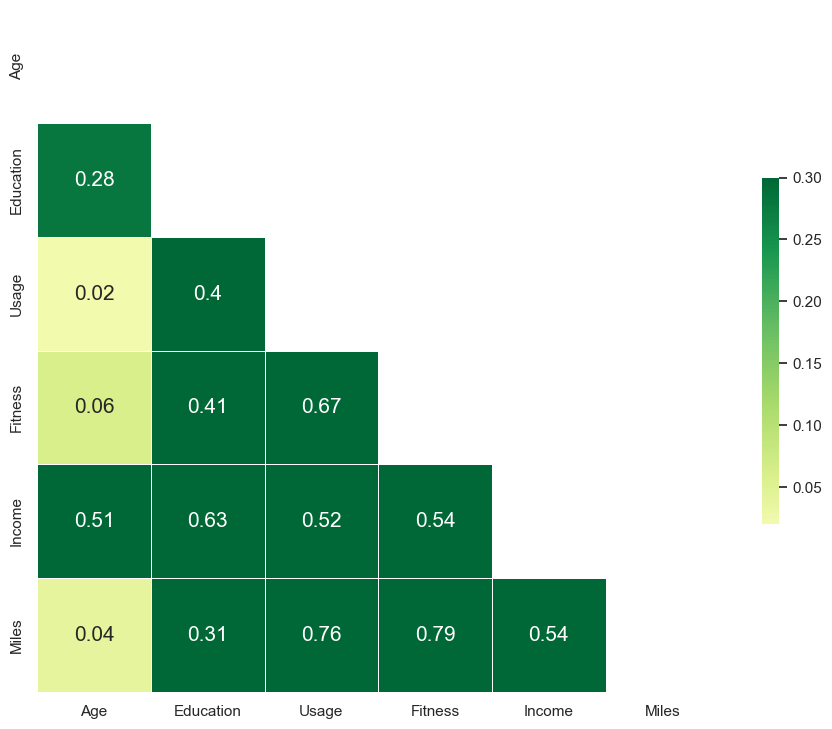

In [117]:
# numerical - correlogram
def graph_correlogram(df):
    sns.set_theme(style="white") 
    # Compute the correlation matrix (use round to change decimals)
    corr = df.corr(numeric_only=True).round(2)
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))
    # Draw the heatmap with the mask and correct aspect ratio
    graph = sns.heatmap(
        corr, mask=mask, cmap='RdYlGn', vmax=.3, center=0, square=True,
        annot=True, linewidths=.5,
        cbar_kws={"shrink": .5}, annot_kws={"fontsize":15})
    return graph

graph_correlogram(df)

### Correlation Matrix

In [118]:
# correlation matrix with p-values
def df_correlation_matrix(df):
    numerical = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f'Pearson Correlation Matrix with P-Values')
    print(f'[Coef in Btm Tri / p-Values in Up Tri]')
    print(f'*** for <0.001, ** for <0.01, * for <0.05')
    print(f'-----------------------------------------')
    return df[numerical].rcorr(method='pearson').round(3)

df_correlation_matrix(df)

Pearson Correlation Matrix with P-Values
[Coef in Btm Tri / p-Values in Up Tri]
*** for <0.001, ** for <0.01, * for <0.05
-----------------------------------------


,Age,Education,Usage,Fitness,Income,Miles
Age,-,***,,,***,
Education,0.28,-,***,***,***,***
Usage,0.015,0.395,-,***,***,***
Fitness,0.061,0.411,0.669,-,***,***
Income,0.513,0.626,0.52,0.535,-,***
Miles,0.037,0.307,0.759,0.786,0.543,-


# Histograms of Numerical

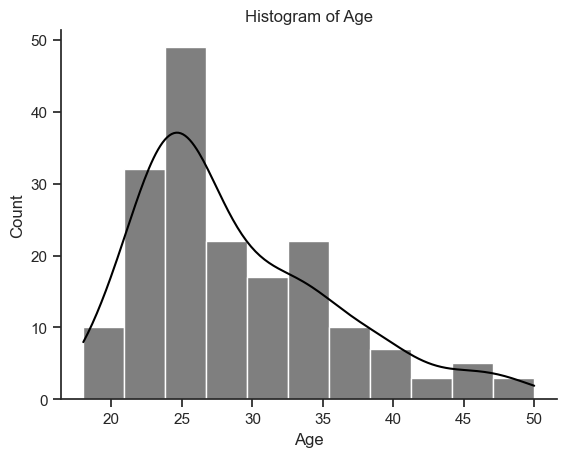

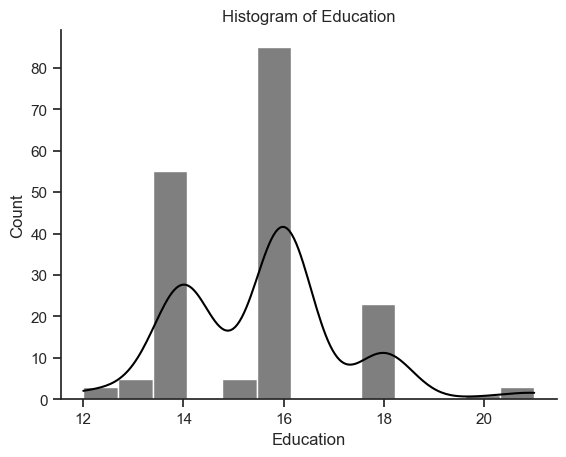

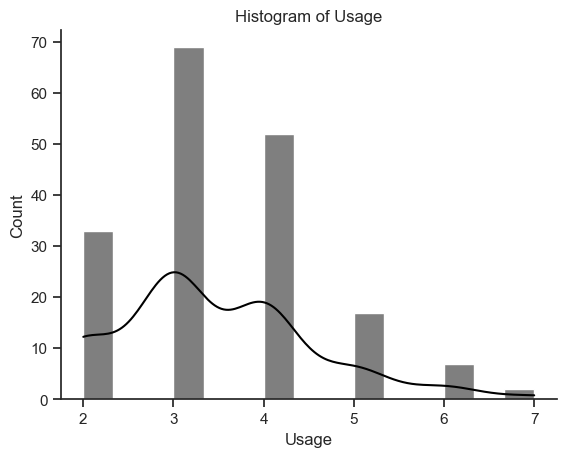

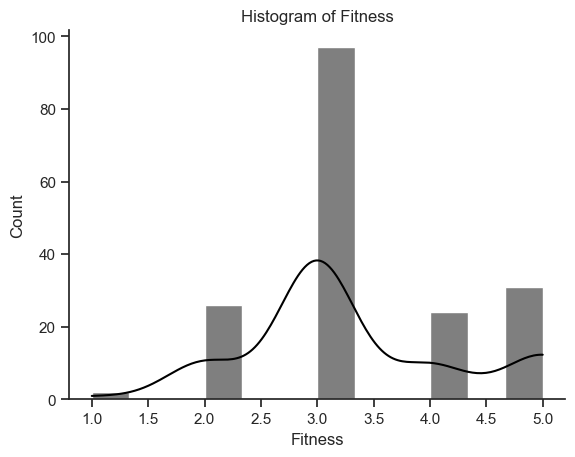

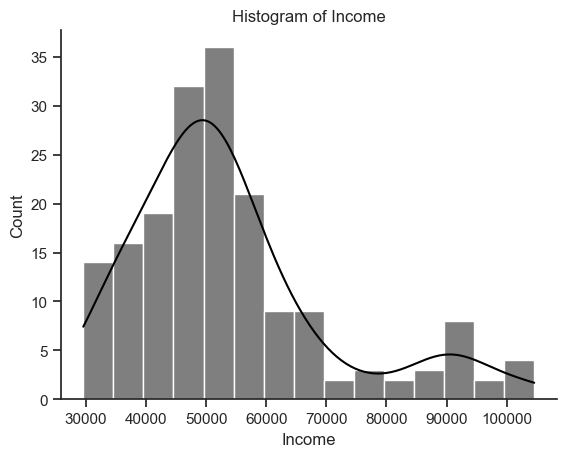

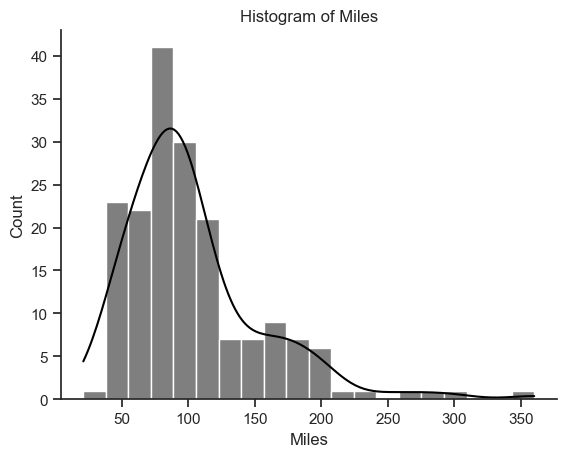

In [119]:
# graph of all numeric data types
def graph_numeric_histograms(df):
    custom_params = {"axes.spines.right": False, "axes.spines.top": False}
    sns.set_theme(style="ticks", rc=custom_params)
    numeric_columns = df.select_dtypes(include=np.number)
    for col in numeric_columns:
        sns.histplot(df[col], kde=True, color='black')
        plt.title(f'Histogram of {col.title()}')
        plt.show()
    
graph_numeric_histograms(df)

# Analysis of Variation

## All vs Product

In [120]:
def get_anova_df(target, df, is_target_cat=True):
    # libraries
    import warnings
    import pandas as pd
    import numpy as np
    import pingouin as pg
    
    if is_target_cat:
        # filter warnings
        warnings.simplefilter(action='ignore', category=FutureWarning)
        # get numeric features
        numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
        # empty dataframe
        anova_df = pd.DataFrame()
        # loop over numeric features and run anova on cat
        for num in numerical_columns:
            new_row = df.anova(dv=num, between=target, detailed=False).round(4)
            new_row['Target'] = num
            new_row = new_row.rename(columns={'Target':'Source', 'Source':'Target'})
            anova_df = pd.concat([anova_df, new_row], axis='rows')
            anova_df['S.S. Diff'] = ['Yes' if p <= 0.05 else 'No' for p in anova_df['p-unc']]
        # reorder df
        anova_df = anova_df[['Target', 'Source', 'ddof1', 'ddof2', 'F', 'p-unc', 'np2', 'S.S. Diff']]
        return anova_df.round(4)
    else:
        # filter warnings
        warnings.simplefilter(action='ignore', category=FutureWarning)
        # get categorical features
        categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
        # empty dataframe
        anova_df = pd.DataFrame()
        # loop over categorical features and run anova on num
        for cat in categorical_columns:
            new_row = df.anova(dv=target, between=cat, detailed=False)
            anova_df = pd.concat([anova_df, new_row], axis='rows')
            anova_df['S.S. Diff'] = ['Yes' if p <= 0.05 else 'No' for p in anova_df['p-unc']]
        anova_df['Target'] = target
        # reorder columns
        anova_df = anova_df[['Target', 'Source', 'ddof1', 'ddof2', 'F', 'p-unc', 'np2', 'S.S. Diff']]
        return anova_df.round(4)

In [121]:
get_anova_df('Product', df, True)

,Target,Source,ddof1,ddof2,F,p-unc,np2,S.S. Diff
0,Product,Age,2,177,0.0942,0.9101,0.0011,No
0,Product,Education,2,177,45.1904,0.0000,0.3380,Yes
0,Product,Usage,2,177,65.4445,0.0000,0.4251,Yes
0,Product,Fitness,2,177,104.0013,0.0000,0.5403,Yes
0,Product,Income,2,177,89.2590,0.0000,0.5021,Yes
0,Product,Miles,2,177,68.2418,0.0000,0.4354,Yes


## Pairwise Test

In [122]:
def pw_comp(cat, num, data):
    # calculate effect size
    def get_eff_size(g):
        if np.abs(g) <= 0.2:
            return 'Small'
        elif np.abs(g) <= 0.5:
            return 'Medium'
        else:
            return 'Large'
    # graph
    graph = sns.boxplot(y=cat, x=num, data=data)
    plt.suptitle(f'Boxplot of {cat.title()} vs {num.title()}')
    plt.show()
    
    # display means
    display(pd.DataFrame(data.groupby(cat)[num].mean()))
    
    # add new columns
    aov_df = pg.pairwise_tukey(dv=num, between=cat, data=df).round(4)
    aov_df['S.S. Diff'] = ['Yes' if p <= 0.05 else 'No' for p in aov_df['p-tukey']]
    aov_df['Eff Size'] = aov_df['hedges'].apply(get_eff_size)
    
    display(aov_df)

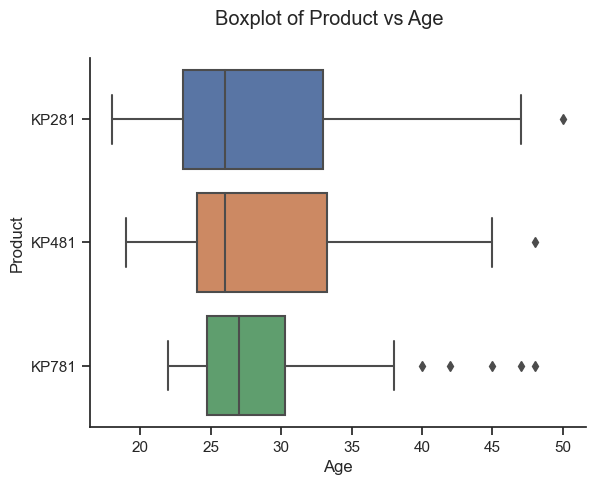

,Age
Product,
KP281,28.55
KP481,28.90
KP781,29.10


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,28.55,28.9,-0.35,1.1919,-0.2937,0.9536,-0.0499,No,Small
1,KP281,KP781,28.55,29.1,-0.55,1.3515,-0.4070,0.9128,-0.0765,No,Small
2,KP481,KP781,28.90,29.1,-0.20,1.4246,-0.1404,0.9892,-0.0293,No,Small


In [123]:
pw_comp('Product', 'Age', df)

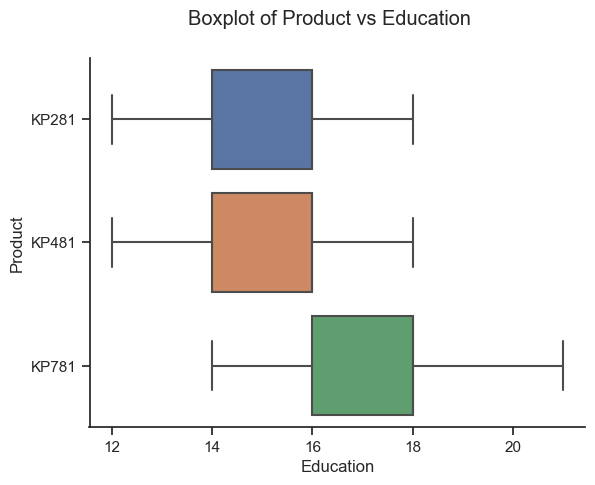

,Education
Product,
KP281,15.037500
KP481,15.116667
KP781,17.325000


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,15.0375,15.1167,-0.0792,0.2260,-0.3504,0.9346,-0.0646,No,Small
1,KP281,KP781,15.0375,17.3250,-2.2875,0.2562,-8.9281,0.0000,-1.6584,Yes,Large
2,KP481,KP781,15.1167,17.3250,-2.2083,0.2701,-8.1768,0.0000,-1.5617,Yes,Large


In [124]:
pw_comp('Product', 'Education', df)

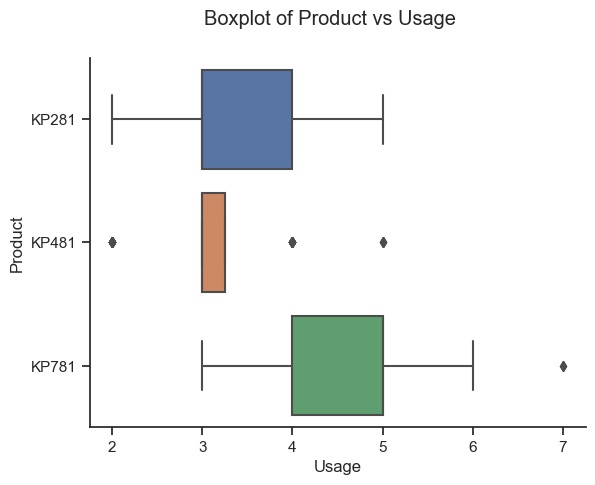

,Usage
Product,
KP281,3.087500
KP481,3.066667
KP781,4.775000


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,3.0875,3.0667,0.0208,0.1413,0.1475,0.9881,0.0262,No,Small
1,KP281,KP781,3.0875,4.7750,-1.6875,0.1602,-10.5354,0.0000,-1.9949,Yes,Large
2,KP481,KP781,3.0667,4.7750,-1.7083,0.1688,-10.1181,0.0000,-1.9681,Yes,Large


In [125]:
pw_comp('Product', 'Usage', df)

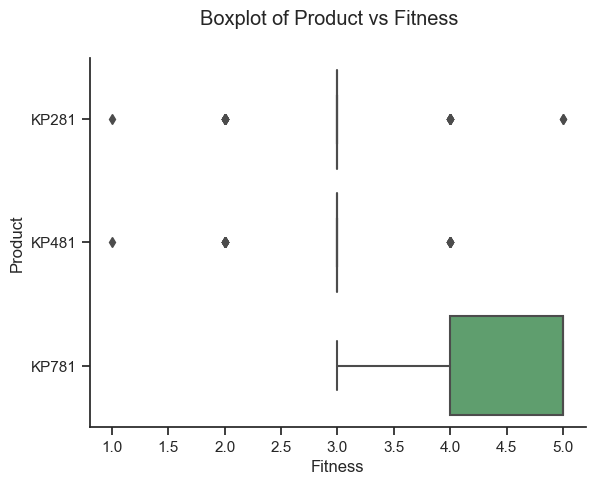

,Fitness
Product,
KP281,2.9625
KP481,2.9000
KP781,4.6250


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,2.9625,2.900,0.0625,0.1117,0.5597,0.8416,0.0956,No,Small
1,KP281,KP781,2.9625,4.625,-1.6625,0.1266,-13.1308,0.0000,-2.4822,Yes,Large
2,KP481,KP781,2.9000,4.625,-1.7250,0.1335,-12.9253,0.0000,-2.6538,Yes,Large


In [126]:
pw_comp('Product', 'Fitness', df)

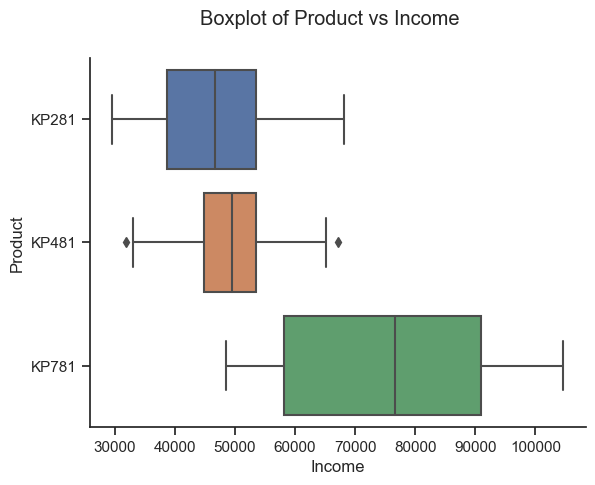

,Income
Product,
KP281,46418.025
KP481,48973.650
KP781,75441.575


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,46418.025,48973.650,-2555.625,2000.3174,-1.2776,0.4097,-0.2857,No,Medium
1,KP281,KP781,46418.025,75441.575,-29023.550,2268.1468,-12.7962,0.0000,-2.2227,Yes,Large
2,KP481,KP781,48973.650,75441.575,-26467.925,2390.8366,-11.0706,0.0000,-1.9502,Yes,Large


In [127]:
pw_comp('Product', 'Income', df)

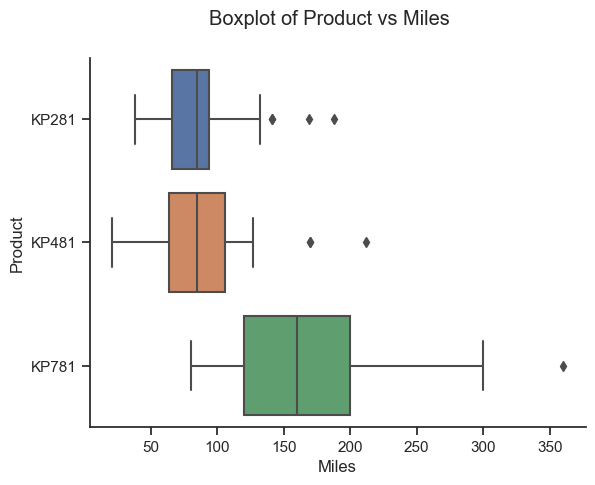

,Miles
Product,
KP281,82.787500
KP481,87.933333
KP781,166.900000


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges,S.S. Diff,Eff Size
0,KP281,KP481,82.7875,87.9333,-5.1458,6.6931,-0.7688,0.7226,-0.1660,No,Small
1,KP281,KP781,82.7875,166.9000,-84.1125,7.5892,-11.0831,0.0000,-1.9975,Yes,Large
2,KP481,KP781,87.9333,166.9000,-78.9667,7.9997,-9.8711,0.0000,-1.7092,Yes,Large


In [128]:
pw_comp('Product', 'Miles', df)

# Chi Sqi Test

In [129]:
def get_chi_sq_df(target, df):
    # filter warnings
    warnings.simplefilter(action='ignore', category=FutureWarning)
    categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()
    categorical_columns.remove(target)
    # empty df
    chi_sq_df = pd.DataFrame()
    # loop through df, add row for each pair
    for cat in categorical_columns:
        _,_,new_row = pg.chi2_independence(data=df, x=target, y=cat)
        new_row = new_row.loc[new_row['test']=='pearson']
        new_row['Target'] = target
        new_row['Categorical Feature'] = cat
        chi_sq_df = pd.concat([chi_sq_df, new_row], axis='rows')
        chi_sq_df['S.S. Diff'] = ['Yes' if p <= 0.05 else 'No' for p in chi_sq_df['pval']]
        chi_sq_df = chi_sq_df[['Target', 'Categorical Feature', 'test', 'chi2', 'dof', 'pval', 'cramer', 'power', 'S.S. Diff']]
    return chi_sq_df.round(4)

In [130]:
get_chi_sq_df('Product', df)

,Target,Categorical Feature,test,chi2,dof,pval,cramer,power,S.S. Diff
0,Product,Gender,pearson,12.9238,2.0,0.0016,0.2680,0.9063,Yes
0,Product,MaritalStatus,pearson,0.0807,2.0,0.9605,0.0212,0.0561,No


In [131]:
def chi_sq_info(x,y,data):
    # get info from chi sq test
    expected, observed, stats = pg.chi2_independence(data=data, x=x, y=y)
    def chi_sq_conc(p):
        if p <= 0.05:
            return 'Dependent'
        else:
            return 'Independent'
    # result of chi sq test
    stats['Conclusion'] = stats['pval'].apply(chi_sq_conc)
    
    # function for effect size
    def eff_size(c):
        if c <= 0.2:
            return 'Weak'
        elif c <= 0.6:
            return 'Moderate'
        else:
            return 'Strong'
    
    # add effect size column
    stats['Effect Size'] = stats['cramer'].apply(eff_size)
    
    # expected frequencies into a dataframe
    expected_melted = expected.reset_index().melt(id_vars=x)
    
    # observed frequencies into a dataframe
    observed_melted = observed.reset_index().melt(id_vars=x)
    
    # graph of expected frequencies
    sns.catplot(data=expected_melted, x=x, y="value", col=y, kind="bar")
    plt.suptitle('Expected Frequencies')
    
    # graph of observed frequencies
    sns.catplot(data=observed_melted, x=x, y="value", col=y, kind="bar")
    plt.suptitle('Observed Frequencies')
    plt.show()
    
    # expected frequencies contingency table
    print(f'The expected contingency table of frequencies.')
    display(expected.round(4))

    
    # observed frequencies contingency table
    print(f'The observed contingency table of frequencies.')
    display(observed.round(4))
    
    # test summary
    print(f'The test summary:')
    display(stats.loc[stats['test']=='pearson'].round(4))

/Users/waddles/miniconda3/envs/my_env/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/waddles/miniconda3/envs/my_env/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


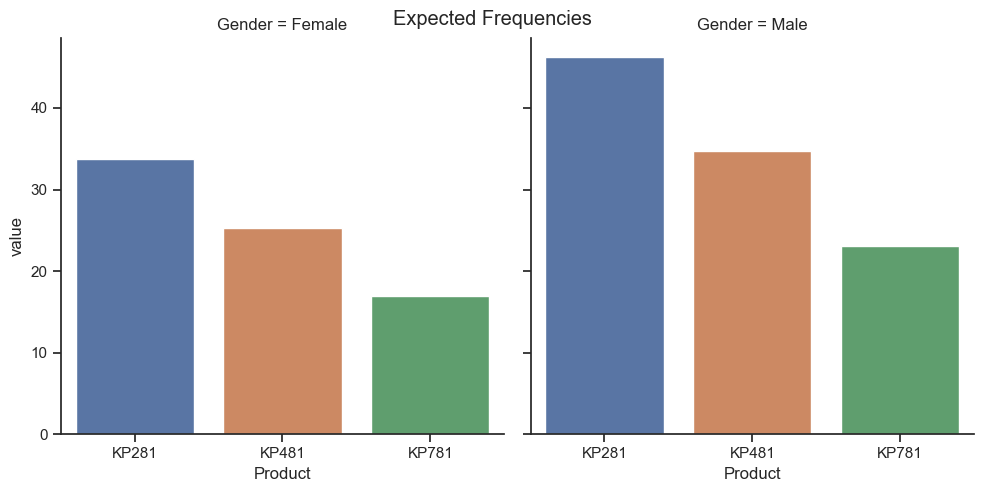

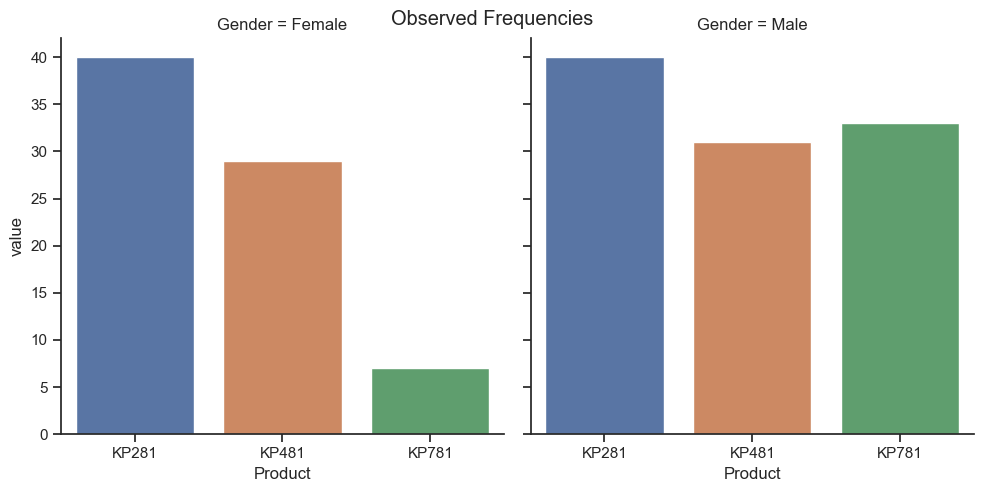

The expected contingency table of frequencies.


Gender,Female,Male
Product,,
KP281,33.7778,46.2222
KP481,25.3333,34.6667
KP781,16.8889,23.1111


The observed contingency table of frequencies.


Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


The test summary:


,test,lambda,chi2,dof,pval,cramer,power,Conclusion,Effect Size
0,pearson,1.0,12.9238,2.0,0.0016,0.268,0.9063,Dependent,Moderate


In [132]:
chi_sq_info('Product', 'Gender', df)

/Users/waddles/miniconda3/envs/my_env/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/Users/waddles/miniconda3/envs/my_env/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


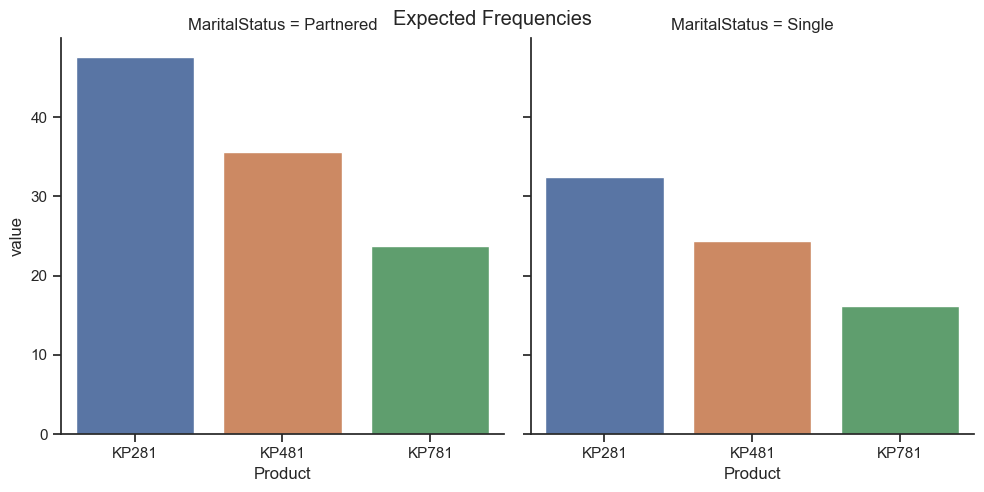

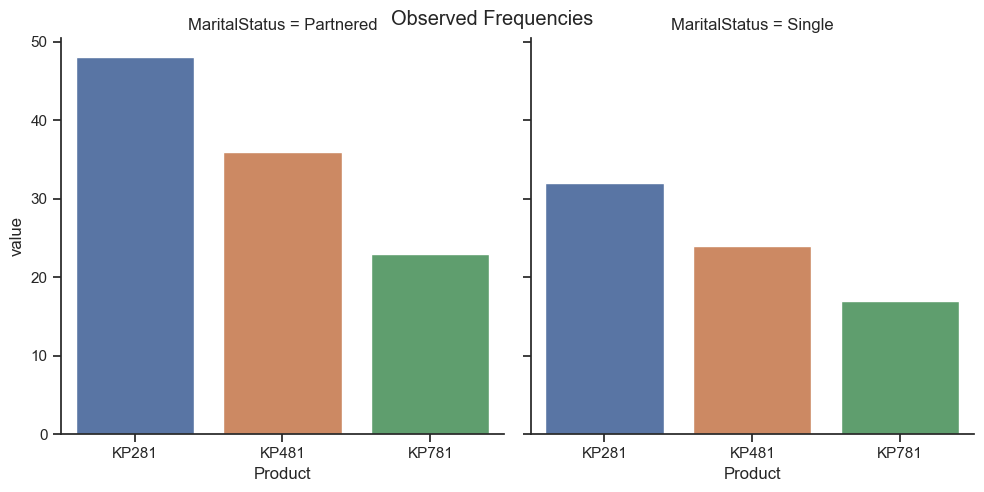

The expected contingency table of frequencies.


MaritalStatus,Partnered,Single
Product,,
KP281,47.5556,32.4444
KP481,35.6667,24.3333
KP781,23.7778,16.2222


The observed contingency table of frequencies.


MaritalStatus,Partnered,Single
Product,,
KP281,48,32
KP481,36,24
KP781,23,17


The test summary:


,test,lambda,chi2,dof,pval,cramer,power,Conclusion,Effect Size
0,pearson,1.0,0.0807,2.0,0.9605,0.0212,0.0561,Independent,Weak


In [133]:
chi_sq_info('Product', 'MaritalStatus', df)